# Tutorial 6: LGG

# End-to-end scFO workflow using a low-grade glioma (LGG) atlas

In this tutorial, we'll show a start to finish workflow for constructing an `scfo` object, visualizing factors/feature loadings, and projecting onto external data. We'll use factors/priors from our atlas of LGG single cells (>400,000 cells from approx. 70 biopsies/10 studies). We'll project onto LGG bulk RNA-seq data from 4 studies (TCGA, CGGA, GLASS, Gravendeel) that were deconvolved using CIBERSORTx + our atlas as a single cell reference.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo

# Building the Ontology object

**For detailed instructions on how to create the object below, see Tutorial #1: Object Construction**

First we'll load our factors:

In [2]:
all_mofa = pd.read_csv('Priors/all_lgg_mofa_weights_no_pt.csv', index_col = 0).fillna(0)
all_mofa

,Factor0|Tumor,Factor1|Tumor,Factor2|Tumor,Factor3|Tumor,Factor4|Tumor,Factor5|Tumor,Factor6|Tumor,Factor7|Tumor,Factor8|Tumor,Factor9|Tumor,...,Factor15|Non_Mac_Myelocyte,Factor16|Non_Mac_Myelocyte,Factor17|Non_Mac_Myelocyte,Factor18|Non_Mac_Myelocyte,Factor19|Non_Mac_Myelocyte,Factor20|Non_Mac_Myelocyte,Factor21|Non_Mac_Myelocyte,Factor22|Non_Mac_Myelocyte,Factor23|Non_Mac_Myelocyte,Factor24|Non_Mac_Myelocyte
HS3ST1,1.699422e-02,-0.012411,2.760737e-03,-2.397406e-02,-0.018595,-1.366158e-02,1.164200e-02,-0.004593,-5.697068e-06,-0.004601,...,0.000103,0.012319,-0.001229,-0.017047,0.007698,0.001443,-0.017141,-1.562448e-06,-5.663493e-06,3.728090e-36
TMEM176A,9.073949e-04,-0.000002,-2.944116e-04,-2.405923e-07,-0.000308,-2.885547e-04,2.726346e-06,0.000605,1.191407e-05,-0.000242,...,-0.010485,-0.037657,-0.000674,0.005191,-0.001039,-0.000664,0.029051,2.909371e-06,3.046963e-04,-9.308141e-35
CASP10,-7.447127e-08,0.000364,-8.008752e-08,-4.166910e-08,0.000003,5.448517e-07,3.384825e-08,-0.000013,5.410866e-08,-0.000245,...,-0.000085,-0.000358,-0.000179,0.015764,0.001746,-0.000708,-0.001561,-3.164791e-07,-3.848641e-05,9.028951e-35
CFLAR,6.056193e-03,-0.003189,1.013270e-02,3.512517e-02,-0.019514,-7.821678e-05,4.010526e-02,-0.022557,-1.200610e-02,-0.000031,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
TFPI,1.492360e-02,-0.004856,-1.708039e-03,-1.657408e-03,-0.004228,1.781760e-06,4.535918e-03,0.007128,7.764774e-03,0.003524,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF512,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,...,-0.003137,-0.000003,-0.000027,-0.000136,-0.000418,-0.001002,0.000010,-1.443814e-06,-2.031494e-05,-2.328201e-36
ALG11,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,...,0.000094,-0.000042,0.000182,-0.000088,-0.000106,-0.000164,0.000022,-6.346010e-07,-1.652171e-04,6.712144e-37
PRKDC,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,...,0.055972,0.003956,0.059450,-0.032705,0.042208,0.042831,-0.041774,4.203315e-06,-6.176139e-04,9.221335e-34
MAP1LC3B2,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,...,0.000041,-0.000056,0.000014,-0.000010,-0.000035,-0.000012,0.000044,-5.665279e-08,7.744960e-07,4.687612e-36


Then we'll load the priors:

In [3]:
all_regulons = pd.read_csv('Priors/all_lgg_regulons.csv', index_col = 0).fillna(0)
all_liana = pd.read_csv('Priors/all_lgg_liana.csv', index_col = 0).fillna(0)
all_survival_scores = pd.read_csv('Priors/all_surivial_score_loadings.csv', index_col = 0).fillna(0)
all_nichenet = pd.read_csv('Priors/nichenet_downstream.csv', index_col = 0).fillna(0)
all_treatment = pd.read_csv('scfo_input/all_treatment.csv', index_col = 0).fillna(0)

gene_sets = pd.read_csv('Priors/all_signatures.csv')
gene_sets_dict = {}
for sig in gene_sets.columns:
    gene_sets_dict[sig] = list(gene_sets[sig].dropna())

hallmark_lib_dict = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

To format the Liana output:

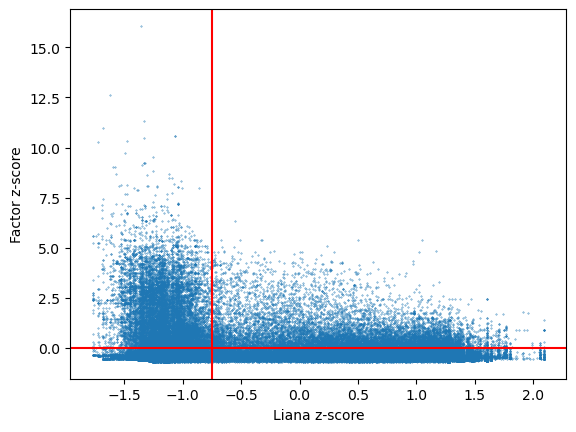

In [4]:
all_liana_send, all_liana_rec, _, _, _ = scfo.make_filtered_lr_signatures(
    liana = all_liana, 
    factor_loadings = all_mofa, 
    liana_z_threshold = -0.75, 
    factor_z_threshold = 0, 
    plot_scores = True
)

Now, to build the object:

In [5]:
ontology = scfo.make_ontology(
    factor_loadings=all_mofa,
    scored_modalities_ct_aware={
        'regulons': all_regulons,
        'liana_ligand': all_liana_send,
        'liana_receptor': all_liana_rec,
        'slice_treatment': all_treatment,
        'survival_scores': all_survival_scores,
    },
    scored_modalities={
        'nichenet_downstream': all_nichenet,
    },
    gene_set_modalities={
       'hallmark': hallmark_lib_dict,
       'literature': gene_sets_dict,
    },
    n_iter=1000,
)

Permuting for 'nichenet_downstream'...:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating GSEA for 'hallmark'...:   0%|          | 0/250 [00:00<?, ?it/s]

Calculating GSEA for 'literature'...:   0%|          | 0/250 [00:00<?, ?it/s]

Permuting for 'regulons'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'regulons'... [Mo_TAM]:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Permuting for 'survival_scores'... [T cell]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Neuron]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Oligo]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Pericyte]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Endothelial]:   0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
ontology

MuData object with n_obs × n_vars = 250 × 14795
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  9 modalities
    weights:	250 x 7728
    nichenet_downstream:	250 x 6988
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type'
      varm:	'feature_loadings'
      layers:	'pval'
    hallmark:	250 x 50
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'gene_sets'
      layers:	'pval'
    literature:	250 x 29
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'gene_sets'
      layers:	'pval'
    regulons:	250 x 610
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_ligand:	250 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_receptor:	250 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    slice_treatment:	250 x 9
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    survival_scores:	250 x 10
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'

To save the object:

In [7]:
ontology.write_h5mu('scfo_mofa_lgg.h5mu')

# Visualizing the Ontology

**For detailed instructions on how to create the plots below, see Tutorial #2: Visualization**

We'll first load our `ontology` object:

In [8]:
ontology = mu.read_h5mu('scfo_mofa_lgg.h5mu')

Let's visualize the top Tumor factor:

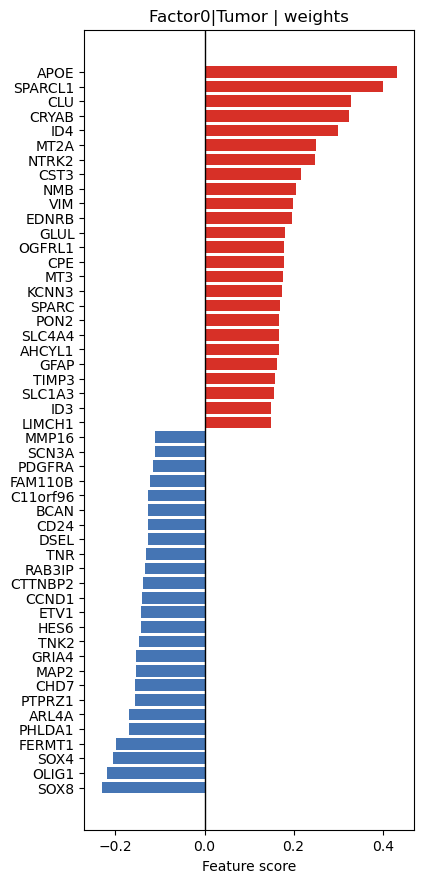

In [9]:
factor = 'Factor0|Tumor'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=25,
    n_neg = 25,
    figsize = (3.3, 8),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

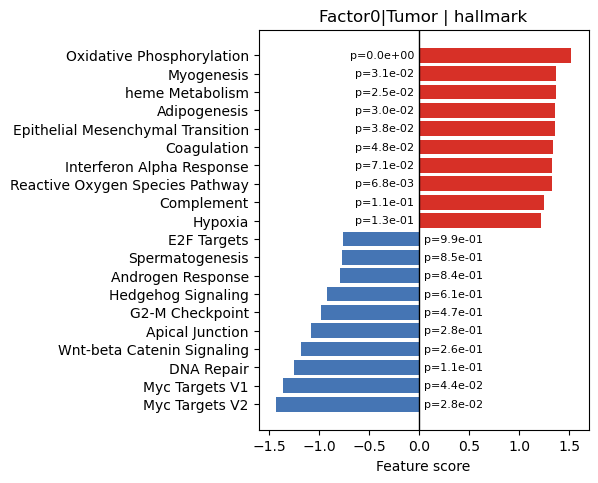

In [10]:
factor = 'Factor0|Tumor'
mod = 'hallmark'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

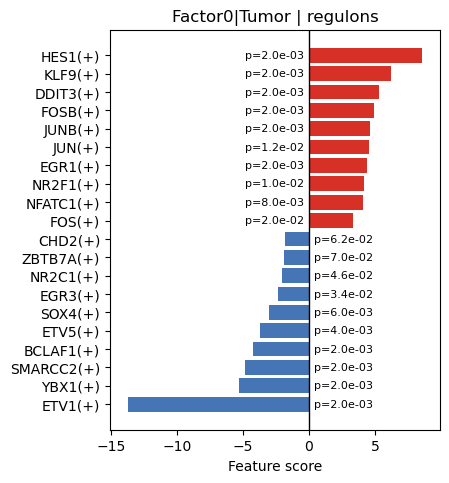

In [11]:
factor = 'Factor0|Tumor'
mod = 'regulons'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

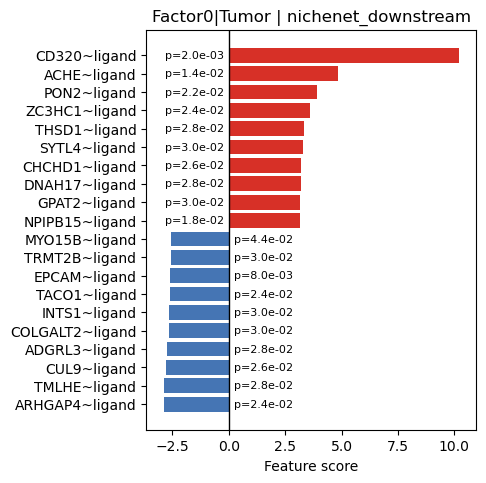

In [12]:
factor = 'Factor0|Tumor'
mod = 'nichenet_downstream'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

In [13]:
tumor_scores = scfo.modality_scores_to_df(
    ontology=ontology, 
    modality='liana_ligand', 
    cell_types='Tumor'
)

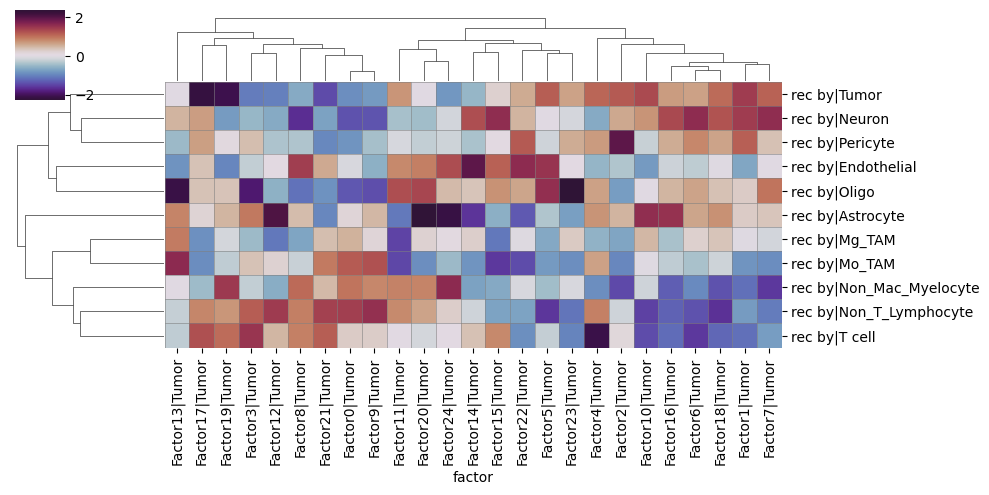

In [14]:
g = sns.clustermap(tumor_scores.T, z_score = 1, cmap = 'twilight_shifted', figsize = (10, 5))
ax = g.ax_heatmap
for x in range(tumor_scores.T.shape[1] + 1):  # columns
    ax.axvline(x, color='grey', linewidth=0.4)

for y in range(tumor_scores.T.shape[0] + 1):  # rows
    ax.axhline(y, color='grey', linewidth=0.4)

# Projecting onto bulk RNA-seq data

**For detailed instructions on how to run the projection process below, see Tutorial #3: Projection**

We'll now project our newly-made LGG `ontology` onto deconvolved bulk RNA-seq data from >500 patients. First, loading and formatting the data:

In [15]:
ontology = mu.read_h5mu('scfo_mofa_lgg.h5mu')

all_bulk_exp_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Pericyte','Endothelial',]:
    if cell_type in ['T cell']:
        cell_type_load = 'Lymphoid'
    else:
        cell_type_load = cell_type
        
    decon_counts = pd.read_csv('CIBERSORTx_Job12_output/CIBERSORTxHiRes_Job12_'+cell_type_load+'_Window36.txt', sep = '\t', index_col = 0)
    decon_counts_sub = decon_counts.dropna().T
    decon_counts_sub.index = decon_counts_sub.index.astype(str) + '~' + cell_type
    all_bulk_exp_ls.append(decon_counts_sub)
all_bulk_exp = pd.concat(all_bulk_exp_ls).fillna(0)
all_bulk_exp_adata = ad.AnnData(all_bulk_exp.copy())
all_bulk_exp_adata.obs['patient'] = all_bulk_exp_adata.obs.index.astype(str).str.split('~').str[0]
all_bulk_exp_adata.obs['cell_type'] = all_bulk_exp_adata.obs.index.astype(str).str.split('~').str[1]
all_bulk_exp_adata

AnnData object with n_obs × n_vars = 4192 × 999
    obs: 'patient', 'cell_type'

Then, projecting onto the bulk `AnnData` using `project_ontology()`:

In [16]:
all_bulk_exp_adata.obs['cell_type'] = all_bulk_exp_adata.obs['cell_type'].astype(str)
scfo.project_ontology(
    adata=all_bulk_exp_adata,
    ontology=ontology,
    annotation_key="cell_type",
    score_key_added="ontology_scores",
    pval_key_added="ontology_pvals",
    method="permutation",
    n_iter=1000,
    inplace=True,
)

collapsed = scfo.collapse_projected_ontology_scores(
    adata=all_bulk_exp_adata,
    score_key="ontology_scores",
    output_key="ontology_scores_collapsed",
    agg="sum",
    store_sparse=False,
)

Permuting Mo_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Mg_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Tumor...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Oligo...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Neuron...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting T cell...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Pericyte...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Endothelial...:   0%|          | 0/1000 [00:00<?, ?it/s]

Reformatting the `collapsed` DataFrame:

In [17]:
collapsed_wide_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Pericyte', 'Endothelial',]:
    collapsed_ct = collapsed.loc[collapsed.index.astype(str).str.contains(cell_type)].copy()
    collapsed_ct.columns = collapsed_ct.columns.astype(str) + '|' + cell_type
    collapsed_ct.index = collapsed_ct.index.astype(str).str.split('~').str[0]
    collapsed_wide_ls.append(collapsed_ct)
mean_scores = pd.concat(collapsed_wide_ls, axis = 1)
mean_scores

factor,Factor0|Mo_TAM,Factor1|Mo_TAM,Factor10|Mo_TAM,Factor11|Mo_TAM,Factor12|Mo_TAM,Factor13|Mo_TAM,Factor14|Mo_TAM,Factor15|Mo_TAM,Factor16|Mo_TAM,Factor17|Mo_TAM,...,Factor22|Endothelial,Factor23|Endothelial,Factor24|Endothelial,Factor3|Endothelial,Factor4|Endothelial,Factor5|Endothelial,Factor6|Endothelial,Factor7|Endothelial,Factor8|Endothelial,Factor9|Endothelial
CGGA_1309,3.083540,0.869342,-1.695939,-2.395521,2.211422,0.225889,-0.181013,-3.497577,-0.630446,-5.827604,...,-1.147051,2.446168,-1.460712,1.469205,0.173899,1.319752,3.446948,6.399640,-1.900499,4.424763
CGGA_632,3.073893,0.866332,-1.700122,-2.400692,2.212079,0.228533,-0.181373,-3.506592,-0.623237,-5.827935,...,-4.319135,2.379939,-1.661647,4.055552,0.250941,1.431689,2.040368,4.420747,0.283947,4.061629
CGGA_1169,3.136095,0.912376,-1.685218,-2.405760,2.262637,0.236910,-0.175863,-3.498854,-0.657476,-5.824320,...,-1.080982,2.484989,-1.452442,1.254859,0.204814,1.101939,3.290173,6.103062,-1.688834,4.124893
CGGA_898,3.086925,0.885500,-1.692053,-2.410547,2.241440,0.237298,-0.179972,-3.511809,-0.628908,-5.826214,...,-0.998605,2.610140,-1.425397,1.129322,0.166218,0.920519,2.965748,5.353076,-1.422520,3.627686
CGGA_1621,3.062705,0.862496,-1.699933,-2.408273,2.202147,0.228556,-0.181064,-3.505005,-0.623778,-5.827543,...,-1.496945,2.357259,-1.551994,1.758766,0.187494,1.288546,3.276157,6.025305,-1.635352,4.277053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GLSS-HK-0004,3.065731,0.868542,-1.702245,-2.411186,2.223876,0.235388,-0.180782,-3.519589,-0.615568,-5.827667,...,-2.042710,2.828649,-1.518437,1.417273,-0.152957,0.137874,4.365626,5.948651,-1.579725,4.056273
TCGA-TM-A7CF,3.060061,0.860376,-1.700105,-2.408872,2.198722,0.228134,-0.180668,-3.504319,-0.621933,-5.827547,...,-1.139088,3.032907,-1.464836,1.372860,0.164466,1.145078,3.036854,5.659468,-1.493948,3.853444
GLSS-SF-0014,3.107247,0.892834,-1.686842,-2.415720,2.217642,0.229527,-0.175982,-3.483936,-0.661563,-5.824473,...,-1.107392,2.552493,-1.545851,1.175287,0.192945,1.109493,3.524134,6.345471,-1.755209,4.207673
TCGA-TQ-A8XE,3.077468,0.875001,-1.687728,-2.409356,2.203847,0.227070,-0.180923,-3.486972,-0.642872,-5.826025,...,-1.396223,2.935299,-1.507167,1.710492,0.088883,1.238362,3.256146,5.728093,-1.572089,4.024651


Visualizing the projected biopsies with a meta-MOFA model:


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='Mo_TAM' group='group1' with N=524 samples and D=25 features...
Loaded view='Mg_TAM' group='group1' with N=524 samples and D=25 features...
Loaded view='Tumor' group='group1' with N=524 samples and D=25 features...
Loaded view='Oligo' group='group1' with N=524 samples and D=25 features...
Loaded view='Neuron' group='group1' with N=524 samples and D=25 features...
Loa

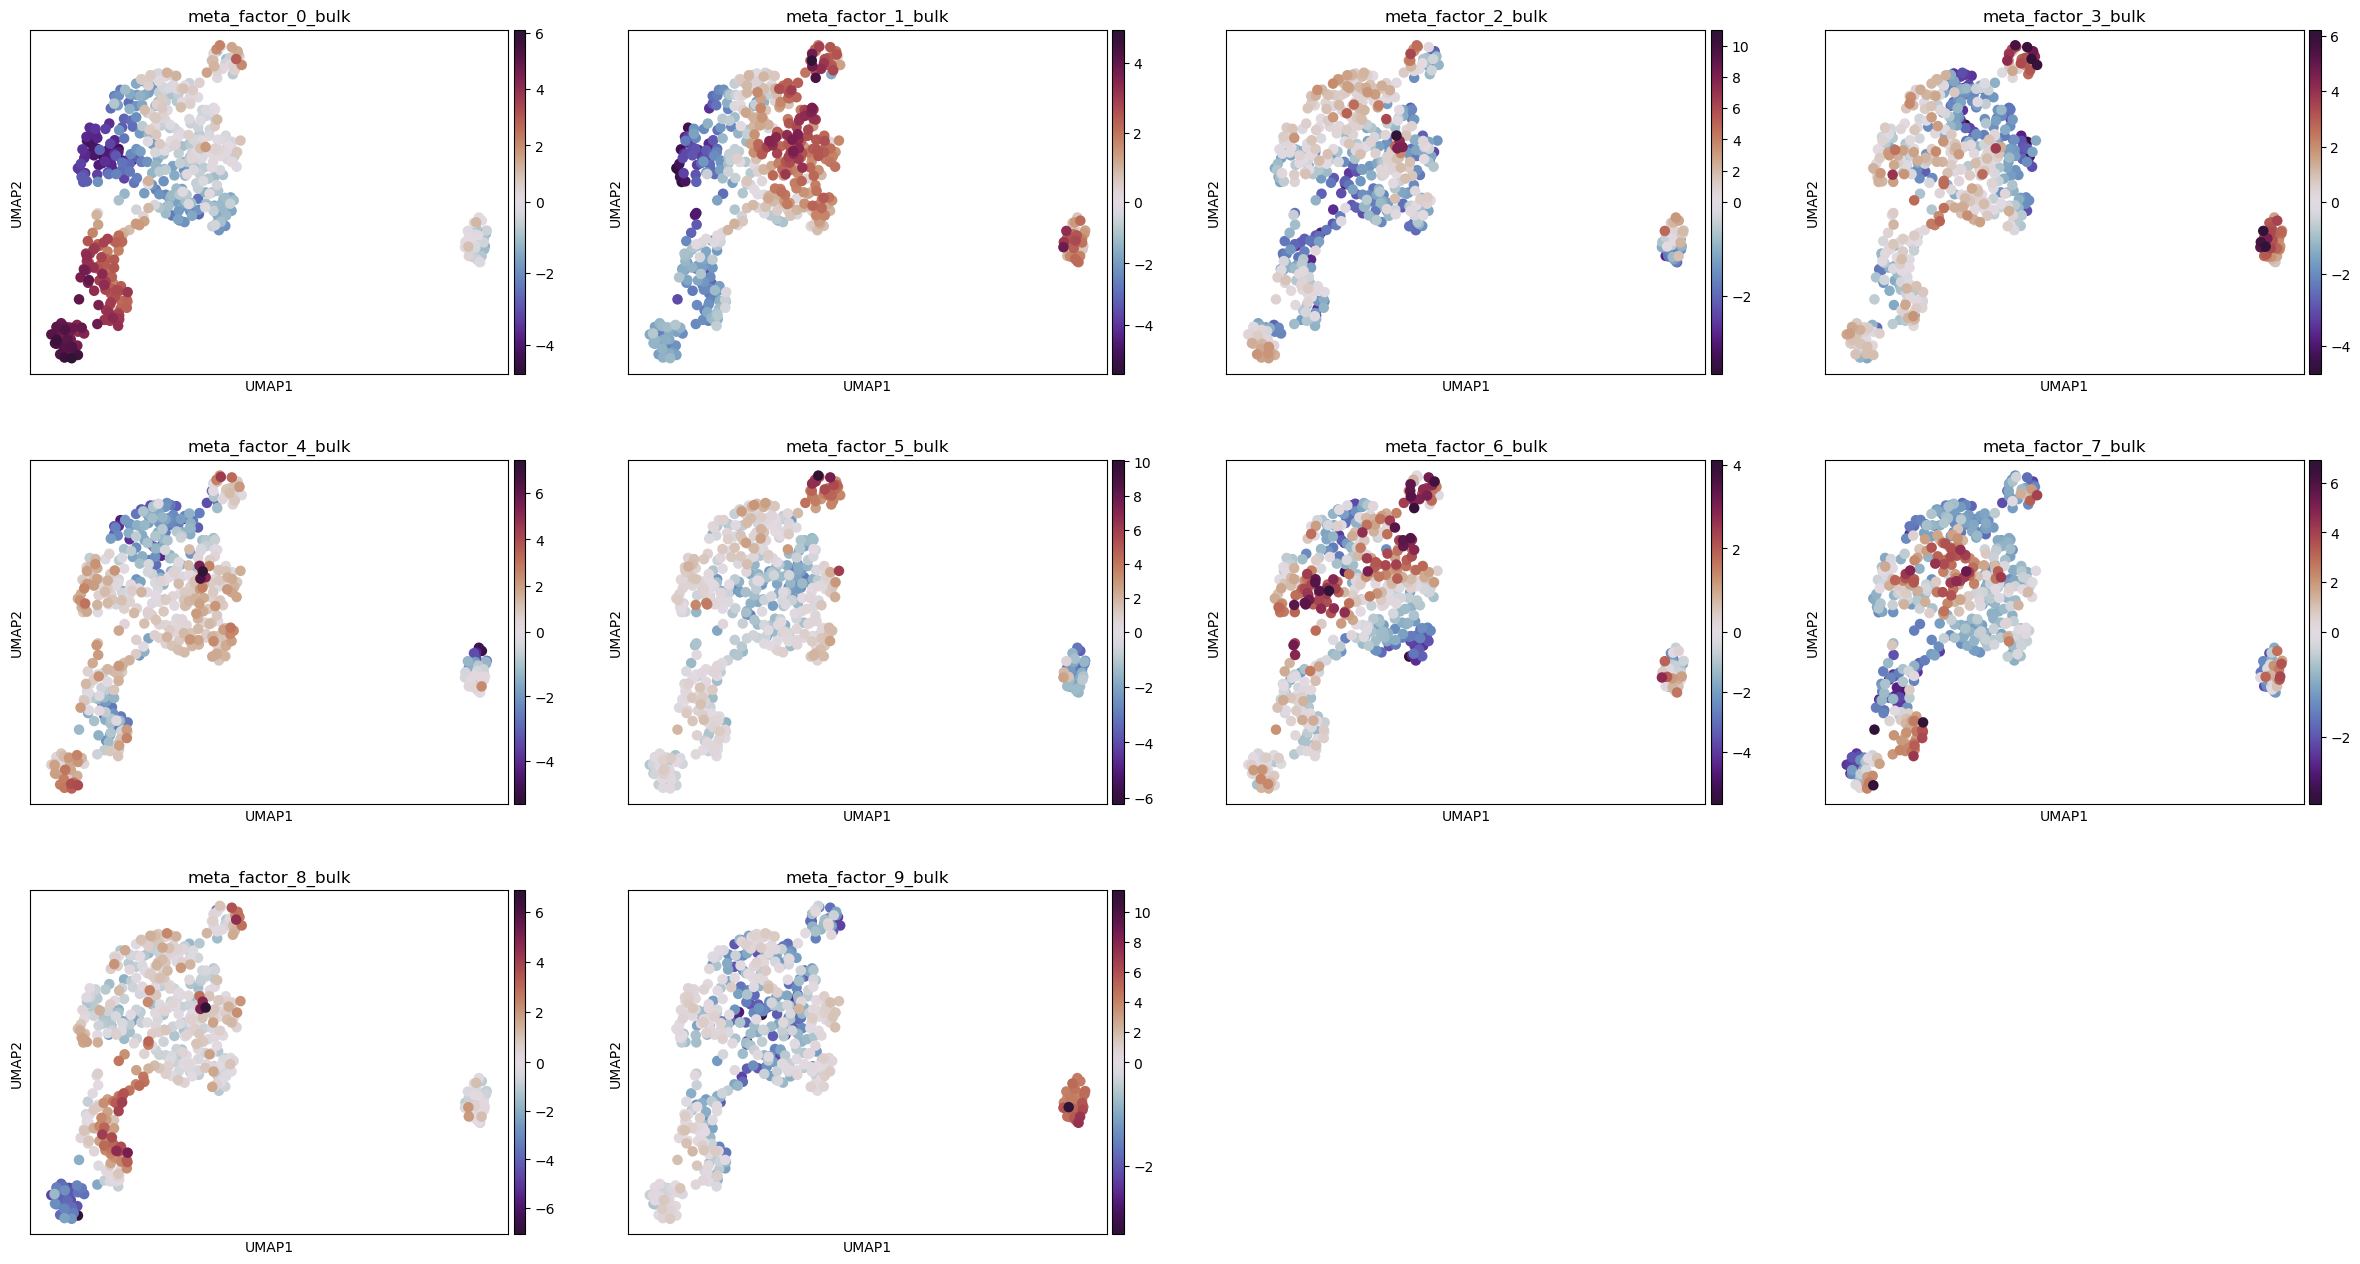

In [18]:
adata_dict = {}
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial',]:
    mean_scores_ct = mean_scores[mean_scores.columns[mean_scores.columns.astype(str).str.contains(cell_type)]].copy()
    mean_scores_ct_z = (mean_scores_ct - mean_scores_ct.mean()) / mean_scores_ct.std()
    adata_dict[cell_type] = ad.AnnData(mean_scores_ct_z)

mean_scores_mdata = mu.MuData(adata_dict)
m = mean_scores_mdata.copy()
m.obs = pd.DataFrame(index=m.obs_names)
m.obs.index = m.obs.index.astype(str)
for col in ["index", "level_0"]:
    if col in m.obs.columns:
        m.obs = m.obs.drop(columns=col)

mu.tl.mofa(m, outfile = 'bulk_biopsies_lgg.hdf5', save_metadata=False,)
meta_mofa_scores_bulk = pd.DataFrame(m.obsm['X_mofa'], index=m.obs.index,)
meta_mofa_weights_bulk = pd.DataFrame(m.varm['LFs'],index=m.var_names,)
meta_mofa_scores_bulk.columns = [f'meta_factor_{i}_bulk' for i in range(meta_mofa_scores_bulk.shape[1])]
meta_mofa_weights_bulk.columns = [f'meta_factor_{i}_bulk' for i in range(meta_mofa_weights_bulk.shape[1])]

sc.pp.neighbors(m, use_rep = 'X_mofa')
sc.tl.umap(m)

m.obs[meta_mofa_scores_bulk.columns] = meta_mofa_scores_bulk.copy()
sc.pl.umap(m, color = meta_mofa_scores_bulk.columns, vcenter = 0, cmap = 'twilight_shifted')

Viewing variance explained: 

<Axes: ylabel='index'>

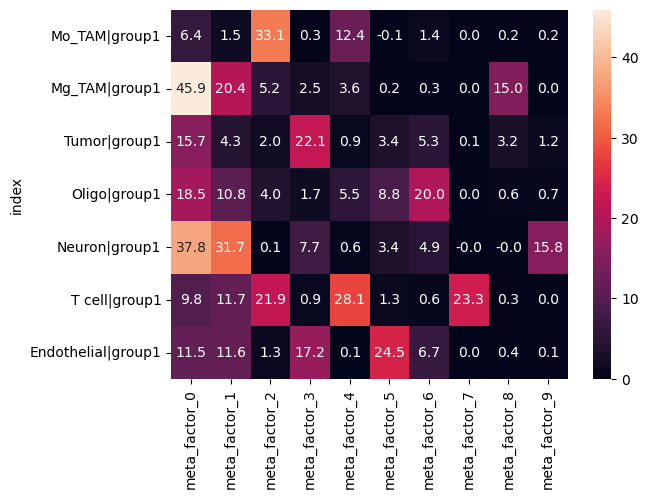

In [19]:
import mofax as mfx
model = mfx.mofa_model("bulk_biopsies_lgg.hdf5")

all_r2_ls = []
for i in range(0, 10):
    r2 = model.calculate_variance_explained(factors = i)
    r2['index'] = r2.View.astype(str) + '|' + r2.Group.astype(str)
    r2.set_index('index', inplace = True)
    all_r2_ls.append(r2.R2)

all_r2 = pd.concat(all_r2_ls, axis = 1)
all_r2.columns = [f'meta_factor_{i}' for i in range(all_r2.shape[1])]
sns.heatmap(all_r2, annot=True, fmt=".1f")

Making a meta-`ontology` object to visualize these meta-factors:

In [20]:
ontology_meta = scfo.make_ontology(
    factor_loadings = meta_mofa_weights_bulk
)
ontology_meta

MuData object with n_obs × n_vars = 10 × 175
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  1 modality
    weights:	10 x 175

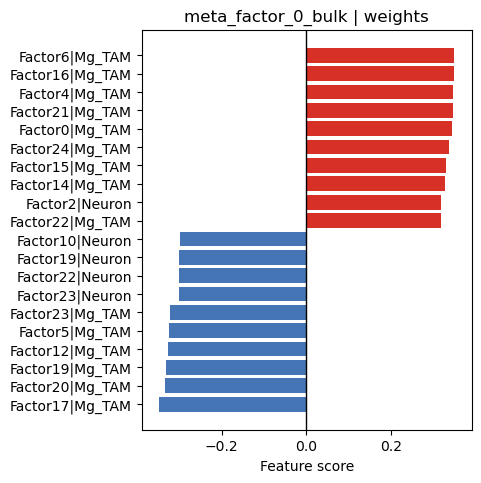

In [21]:
factor = 'meta_factor_0_bulk'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology_meta,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

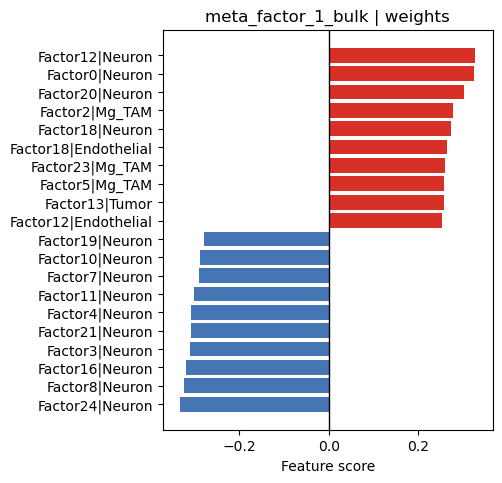

In [22]:
factor = 'meta_factor_1_bulk'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology_meta,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

Great! Now we have an annotated, interpretable, and externally-validated factor-ontology for low grade gliomas.